In [1]:
%load_ext autoreload
%autoreload 2

Load the pre-trained model and the dataset

In [2]:
import numpy as np
import torch
from torch.utils.data import ConcatDataset
from pathlib import Path

from pooling_genomic.datasets import get_tcga_cohort_and_tumor_classification_datasets
from pooling_genomic.models import build_gnn_pooling_tumor_and_cohort_clf, get_fixed_supernodes_convs_list
from pooling_genomic.networks import load_graph_levels
from pooling_genomic.utils import build_data_loaders

max_levels = 7
first_level = 4
random_state = 7
batch_size = 64
num_workers = 1
weighted_pooling = True
save_embedding_grad = True
mlp_hidden_dim = (256, )

path_levels = '/home/thomas/Documents/PoolingGenomicGNNs/data/networks/levels'
device = 'cpu'
graphs = load_graph_levels(
    path_levels=path_levels, n_levels=max_levels, device=device
)

path_dataset = '/home/thomas/Documents/PoolingGenomicGNNs/data/tcga_cohorts_and_tumor_classification'

train_set, val_set, test_set, dataset = get_tcga_cohort_and_tumor_classification_datasets(
    path_dataset=path_dataset, return_original_set=True, random_state=random_state
)
train_set = ConcatDataset([train_set, val_set])
train_loader, test_loader = build_data_loaders(
    train_set, test_set, batch_size=batch_size, num_workers=num_workers, device=device, drop_last=True, shuffle=False
)
cohort_output_dims = dataset.get_n_cohorts()


convs, out_channels = get_fixed_supernodes_convs_list(
    max_levels=max_levels, first_level=first_level
)
num_super_nodes = np.unique(graphs[-1].cluster_indices.cpu()).shape[0]
model = build_gnn_pooling_tumor_and_cohort_clf(
    graphs=graphs,
    gnns=convs,
    mlp_input_dim=num_super_nodes * out_channels,
    mlp_cohort_output_dim=cohort_output_dims,
    weighted_pooling=weighted_pooling,
    save_embedding_grad=save_embedding_grad,
    mlp_hidden_dim=mlp_hidden_dim,
)

path_results = Path('/home/thomas/Documents/PoolingGenomicGNNs/outputs/tcga_cohort_and_tumor_rep0/final_model_results')
path_images = Path('/home/thomas/Documents/PoolingGenomicGNNs/outputs/tcga_cohort_and_tumor_rep0')

path_model = path_results / 'final_model.pt'
model.load_state_dict(torch.load(str(path_model)))
model

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Using dataset from: /home/thomas/Documents/PoolingGenomicGNNs/data/tcga_cohorts_and_tumor_classification
<class 'numpy.ndarray'>
No. of coarsening levels: 7
GNN POOLING INIT
Registering graph as buffer


Sequential(
  (0): GNNPooling(
    (relus): ModuleList(
      (0): ReLU()
      (1): ReLU()
      (2): ReLU()
      (3): ReLU()
      (4): ReLU()
      (5): ReLU()
      (6): ReLU()
    )
    (node_importances): ParameterList(
        (0): Parameter containing: [torch.FloatTensor of size 14133]
        (1): Parameter containing: [torch.FloatTensor of size 7067]
        (2): Parameter containing: [torch.FloatTensor of size 3534]
        (3): Parameter containing: [torch.FloatTensor of size 1767]
        (4): Parameter containing: [torch.FloatTensor of size 884]
        (5): Parameter containing: [torch.FloatTensor of size 442]
        (6): Parameter containing: [torch.FloatTensor of size 221]
    )
    (gnn): ModuleList(
      (0): None
      (1): None
      (2): None
      (3): None
      (4): ChebConv(1, 2, K=2, normalization=sym)
      (5): ChebConv(2, 4, K=2, normalization=sym)
      (6): ChebConv(4, 8, K=2, normalization=sym)
    )
  )
  (1): CohortAndTumorClassifier(
    (cohort_c

Register ReLU hooks

In [3]:
model.eval()

def relu_hook_function(module, grad_in, grad_out):
    if isinstance(module, torch.nn.ReLU):
        return (torch.clamp(grad_in[0], min=0.),)
    
for i, module in enumerate(model.modules()):
    if isinstance(module, torch.nn.ReLU):
        print(f"Registering relu hook to: {model.named_modules()}")
        module.register_backward_hook(relu_hook_function)

Registering relu hook to: <generator object Module.named_modules at 0x7fca53497d10>
Registering relu hook to: <generator object Module.named_modules at 0x7fca53497d80>
Registering relu hook to: <generator object Module.named_modules at 0x7fca53497d10>
Registering relu hook to: <generator object Module.named_modules at 0x7fca53497d80>
Registering relu hook to: <generator object Module.named_modules at 0x7fca53497d10>
Registering relu hook to: <generator object Module.named_modules at 0x7fca53497d80>
Registering relu hook to: <generator object Module.named_modules at 0x7fca53497d10>


Measure the gradients of the tissue type outputs

In [5]:
import torch
import numpy as np
from torch.autograd import Variable


def measure_type_gradients(dataloader, max_batches=None):
    input_grads = []
    Hs = [[] for _ in range(len(model[0].Hs))]
    Hs_grad = [[] for _ in range(len(model[0].Hs_grad))]    
    cohorts = []
    types = []
    for i, batch in enumerate(dataloader, 0):
        if max_batches is not None:
            if i == max_batches:
                break
        
        x, t = batch
        x, t = x.to(device), [t[0].to(device), t[1].to(device)]

        X_var = Variable(x, requires_grad=True)
        y_var = Variable(t[1])
        scores = model(X_var)
        # print(scores)
        scores = scores[1]
        # print(scores)

        # scores = scores[y_var == 0]  # get the ones marked as tumor
        # print(scores)
        # loss = torch.log(1 - torch.sigmoid(scores[y_var == 0])) + torch.log(torch.sigmoid(scores[y_var == 1]))
        loss = y_var * torch.log(torch.sigmoid(scores)) + (1 - y_var) * torch.log(1 - torch.sigmoid(scores))
        # print(loss)
        loss = -torch.sum(loss)
        # print(loss)
        loss.backward()
        with torch.no_grad():
            input_grads.append(X_var.grad.data.detach().cpu().numpy())
            cohorts.append(t[0].detach().cpu().numpy())
            types.append(t[1].detach().cpu().numpy())
            
            for i, (H, H_grad) in enumerate(zip(model[0].Hs, model[0].Hs_grad)):
                Hs[i].append(H.detach().cpu().numpy())
                Hs_grad[i].append(H_grad.detach().cpu().numpy())

    input_grads = np.concatenate(input_grads, axis=0)
    cohorts = np.concatenate(cohorts, axis=0)
    types = np.concatenate(types, axis=0)
    for lvl in range(len(Hs)):
        Hs[lvl] = np.concatenate(Hs[lvl], axis=0)
        Hs_grad[lvl] = np.concatenate(Hs_grad[lvl], axis=0)

    return input_grads, Hs, Hs_grad, cohorts, types
    
grads, Hs, Hs_grad, cohorts, types = measure_type_gradients(train_loader, None)
grads = np.abs(grads)

In [6]:
Hs[6].shape

(6144, 111, 8)

Analysis of the distribution of the saliencies.
There is a strong knee near 3000 genes. After that, the maximum value drops virtually to 0, indicating that these genes are irrelevant for the model.

In [7]:
genes = dataset.get_genes()
genes

Index(['9606.ENSP00000349560', '9606.ENSP00000179259', '9606.ENSP00000274811',
       '9606.ENSP00000261383', '9606.ENSP00000389103', '9606.ENSP00000256496',
       '9606.ENSP00000301327', '9606.ENSP00000363260', '9606.ENSP00000349401',
       '9606.ENSP00000368682',
       ...
       '9606.ENSP00000325548', '9606.ENSP00000380421', '9606.ENSP00000385269',
       '9606.ENSP00000380120', '9606.ENSP00000379709', '9606.ENSP00000350698',
       '9606.ENSP00000309233', '9606.ENSP00000257549', '9606.ENSP00000414202',
       '9606.ENSP00000243440'],
      dtype='object', name='Ensembl_ID', length=14133)

In [8]:
grads.shape

(6144, 14133)

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

n_to_show = 14133
grad_means = np.mean(grads, axis=0)
indices = np.argsort(-grad_means)[:n_to_show]
print(indices[:10])
pd.DataFrame(indices).to_csv('tumor_saliency_rank.csv', index=False)
top_genes = pd.Series(genes)[indices]
top_genes = top_genes.apply(lambda x: x.split('.')[1])
top_genes.to_csv('top_genes.csv', index=False, header=False)

# with test: [11866 12927  3876  3416 12650 11377  2688 10901  4164 12939]


[12927 10901 11866  3876  6905 12939 11377 12650  9412  5413]


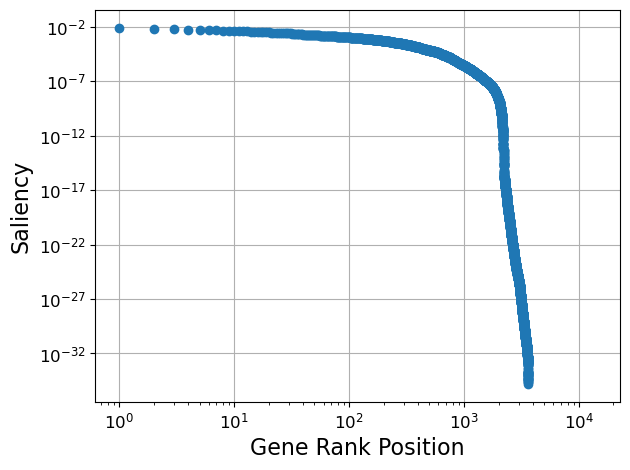

In [31]:
grad_means_s = grad_means[indices]
# grad_std_s = grads.std(axis=0)[indices]

x_val = np.arange(0, grad_means_s.shape[0])
# fig, axs = plt.subplots(1, 2, figsize=(10, 4))
# ax = axs[0]
fig, ax = plt.subplots()
ax.scatter(x_val, grad_means_s)
ax.set_axisbelow(True)
ax.grid()
ax.set_yscale('log')
# ax.set_ylim([1e-7, 1e-3])
ax.set_xscale('log')
ax.set_ylabel('Saliency', fontsize=16)
ax.set_xlabel('Gene Rank Position', fontsize=16)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

# ax = axs[1]
# to_show = 100
# ax.scatter(x_val[:to_show], grad_means_s[:to_show])
# ax.set_axisbelow(True)
# ax.grid()
# ax.set_yscale('log')
# ax.set_xscale('log')
# ax.set_ylabel('Saliency', fontsize=14)
# ax.set_xlabel('Gene Rank Position', fontsize=14)
# ax.xaxis.set_tick_params(labelsize=12)
# ax.yaxis.set_tick_params(labelsize=12)


fig.tight_layout()
fig.savefig(path_images / 'images/gene_distributions.pdf')
# plt.errorbar(x_axis, grad_means_s, yerr=grad_std_s, fmt='o', color='red', capsize=4, label='Error Bars')
plt.show()

Now we check if the embeddings produced by the selected features correctly separate Primary Tumor from Normal tissues.

In [32]:
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
import joblib

path_df_X = '/home/thomas/Documents/Gene Expression Datasets/tcga_cohorts_and_tumor_dataset.joblib'
path_df_y = '/home/thomas/Documents/Gene Expression Datasets/tcga_cohorts_and_tumor_dataset.csv'

df_X = joblib.load(path_df_X)
print(f"df_X Size: {df_X.shape}")
df_y = pd.read_csv(path_df_y, index_col=0)

df_X Size: (14133, 7709)


In [33]:
df_X

,TCGA-DM-A288-01A,TCGA-QL-A97D-01A,TCGA-AZ-5403-01A,TCGA-G4-6299-01A,TCGA-AZ-4315-01A,TCGA-AZ-4614-01A,TCGA-AA-3549-01A,TCGA-AY-4071-01A,TCGA-CM-4752-01A,TCGA-AA-3516-01A,...,TCGA-D1-A16R-01A,TCGA-AP-A5FX-01A,TCGA-AJ-A2QN-01A,TCGA-D1-A1NZ-01A,TCGA-EY-A1GX-01A,TCGA-B5-A0K2-01A,TCGA-D1-A103-01A,TCGA-BG-A220-01A,TCGA-AP-A05O-01A,TCGA-EO-A3KU-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
9606.ENSP00000349560,-0.272150,-1.010451,0.148608,-0.546299,-0.435399,0.036680,-0.201210,1.026587,0.978585,-0.387426,...,1.137013,2.286047,0.664680,0.900740,0.434905,1.660027,0.421028,-1.557939,0.772582,-1.631626
9606.ENSP00000179259,-0.537291,1.184111,2.102102,0.317721,2.354398,0.137713,1.607039,0.208770,1.225852,2.216388,...,-0.797373,-1.045367,0.289649,-1.183446,-0.732177,0.656818,0.096979,-0.397004,0.630974,0.276146
9606.ENSP00000274811,1.952915,1.560490,-0.566675,0.862173,-0.621243,0.231929,1.166821,1.786349,-0.387892,-0.325416,...,0.700401,-0.273401,0.289929,0.358847,-0.399705,-2.093848,-0.109473,1.399417,-0.772664,0.261775
9606.ENSP00000261383,0.991944,0.851904,0.564785,0.532165,0.728986,0.946054,0.695655,1.070346,0.707654,0.761528,...,0.479463,2.099555,1.339941,1.848837,1.610415,1.533124,0.575375,0.318274,1.366421,0.530492
9606.ENSP00000389103,1.406736,-0.579783,0.811180,0.101912,0.348145,0.918104,0.747983,-0.051956,1.338562,-0.068111,...,-0.117204,-0.048816,-0.681638,-0.548858,0.467513,1.470463,-0.224636,-0.217886,0.536933,-0.337794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9606.ENSP00000350698,1.139339,1.076109,-1.225456,-0.504150,1.728173,0.207591,-0.001568,0.113673,-1.138589,-0.479768,...,-0.999895,1.100280,-0.162706,0.436425,0.300680,-1.599957,-0.535032,-0.182454,-1.500253,1.527124
9606.ENSP00000309233,0.072123,0.189287,-0.534064,-0.785994,-0.857259,0.377039,-2.645728,-0.871274,-0.746571,0.740053,...,1.007983,0.774846,-0.418915,-0.278483,0.283682,0.756975,0.363555,-0.921264,0.892592,-1.064186
9606.ENSP00000257549,-0.141783,0.300323,0.373344,0.480560,0.483616,-0.963343,-0.352522,0.722602,-0.183169,0.166385,...,-0.006207,0.662877,0.231085,-0.459480,-0.797352,0.284448,-0.187265,-0.406362,0.491191,0.296705


In [34]:
idx_0 = test_set.idx_0
test_set_len = test_set.ds_len
test_samples = dataset.samples[idx_0:idx_0+test_set_len]

df_X_test = df_X.loc[:, test_samples]
df_y_test = df_y.loc[test_samples, :]

In [35]:
df_y['sample_type'].unique()

array(['Primary Tumor', 'Solid Tissue Normal'], dtype=object)

In [280]:
from sklearn.decomposition import PCA

df_Xs = df_X_test.transpose().iloc[:, indices]

top_n = 100

# Xpc = df_Xs.iloc[:, 0:top_n]
Xpc = df_Xs
# Xpc = PCA(n_components=50).fit_transform(Xpc)
Xpc = TSNE(n_components=2, random_state=123, init='pca', learning_rate='auto').fit_transform(Xpc)

df_pc = pd.DataFrame(Xpc, columns=['t-SNE 1', 't-SNE 2'])
df_pc['type'] = df_y_test['sample_type'].to_numpy()
df_pc['cohort'] = df_y_test['cohort'].to_numpy()
# df_pc['type'] = df_pc['cohort'].astype(str)

fig, ax = plt.subplots()
sns.scatterplot(data=df_pc, x='t-SNE 1', y='t-SNE 2', hue='type', ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel('t-SNE 2', fontsize=14)
ax.set_xlabel('t-SNE 1', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])

# ax.set_title(f'Embedding using the top-{top_n} features', fontsize=14)
ax.set_title(f'Embedding using all features', fontsize=14)

# fig.savefig(path_images / f'images/tsne_top{top_n}_type.pdf')
fig.savefig(path_images / f'images/tsne_all_type.pdf')


NameError: name 'df_X_test' is not defined

In [29]:
df_pc['type'] = df_y['sample_type'].to_numpy()
df_pc

,PC1,PC2,type
0,-12.936685,-68.361115,Primary Tumor
1,-8.724072,-67.630157,Primary Tumor
2,-22.838039,-65.933952,Primary Tumor
3,-4.898372,-51.984791,Primary Tumor
4,-25.391432,-64.811172,Primary Tumor
...,...,...,...
7704,-11.696587,11.472006,Primary Tumor
7705,0.950581,21.414186,Primary Tumor
7706,-4.597861,12.300522,Primary Tumor
7707,-7.709896,18.809074,Primary Tumor


Is there any relation between which genes are important for a certain classification and their cohort?
This type of question could be answered by clustering and by principal component analysis as well. Other ideas? 

PCA definitely doesn't seem to have produced anything meaningful

/home/thomas/miniconda3/envs/pytorch112-cpu-env/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/thomas/miniconda3/envs/pytorch112-cpu-env/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


<AxesSubplot:xlabel='PC1', ylabel='PC2'>

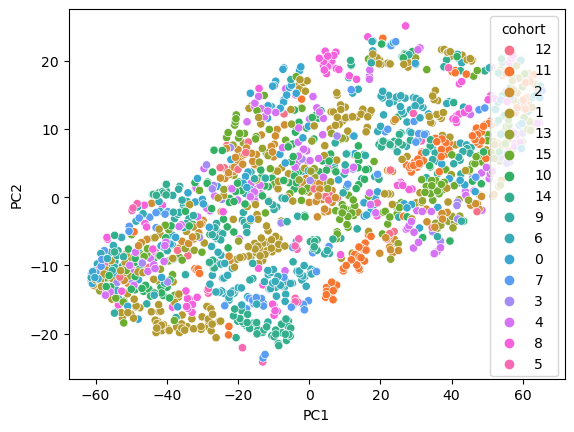

In [165]:
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
grads_s = grads[:, indices]

df_grads = pd.DataFrame(grads_s, columns=indices)
df_grads['cohort'] = cohorts

from sklearn.decomposition import PCA
X = grads_s
y = cohorts
Xpc = TSNE(n_components=2).fit_transform(X)

df_pc = pd.DataFrame(Xpc, columns=['PC1', 'PC2'])
df_pc['cohort'] = cohorts
df_pc['cohort'] = df_pc['cohort'].astype(str)
sns.scatterplot(data=df_pc, x='PC1', y='PC2', hue='cohort')

Besides analyzing the saliencies, one can analyze the pooling weights.
Then try also to understand whether there is a relation between them and the main genes.

[8382 2534 8787 8154 5266  596 2241 7251 9855 9046]


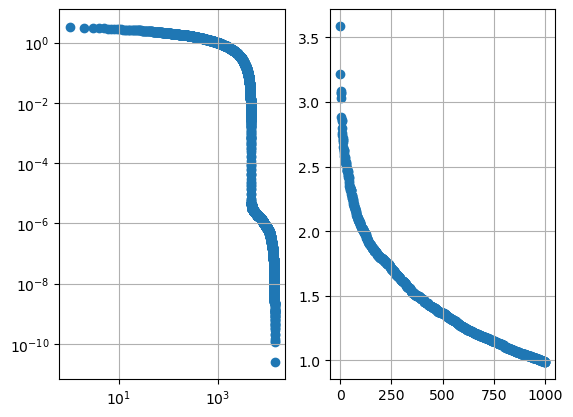

In [166]:
importances = model[0].node_importances[0].detach().numpy()
importance_rank = np.argsort(-np.abs(importances))
importance_ranked = np.abs(importances[importance_rank])
print(importance_rank[:10])

x_axis = np.arange(0, importances.shape[0])
fig, axs = plt.subplots(1, 2)
ax = axs[0]
ax.scatter(x_axis, importance_ranked)
ax.grid()
ax.set_yscale('log')
ax.set_xscale('log')

ax = axs[1]
to_show = 1000
ax.scatter(x_axis[:to_show], importance_ranked[:to_show])
ax.grid()
# ax.set_yscale('log')
# ax.set_xscale('log')

pd.DataFrame(importance_rank).to_csv('tumor_importance_rank.csv', index=False)


We can analyze the saliencies of the nodes as well

Hs shape:  (1536, 111, 8)
Hs_grad shape:  (1536, 111, 8)


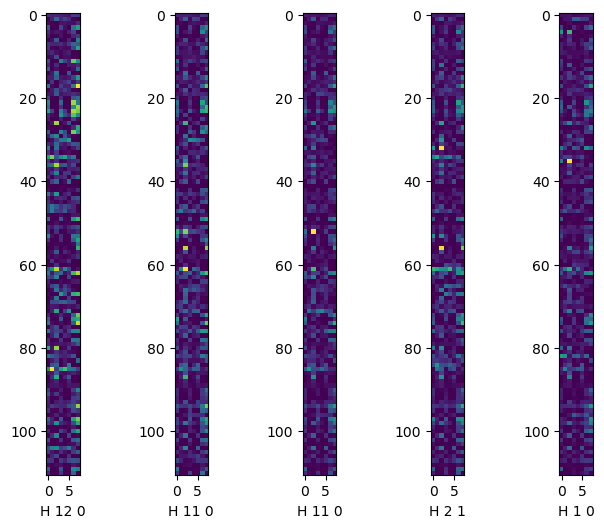

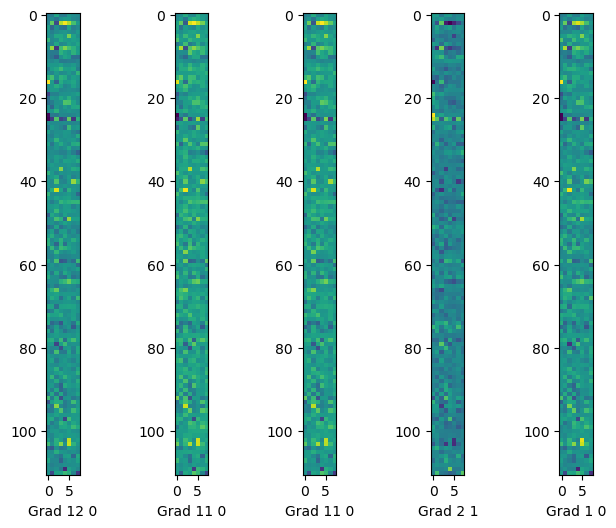

In [170]:
lvl = 6
# Hs = model[0].Hs[lvl].detach().numpy()
# Hs_grad = model[0].Hs_grad[lvl].detach().numpy()

H = Hs[lvl]
H_grad = Hs_grad[lvl]

print("Hs shape: ", H.shape)
print("Hs_grad shape: ", H_grad.shape)

fig, ax = plt.subplots(1, 5, figsize=(8, 6))
for i, ex in enumerate(range(0, 5)):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = H[ex]
    ax[i].imshow(im)
    ax[i].set_xlabel('H {} {}'.format(cohorts[ex], int(types[ex])))

fig, ax = plt.subplots(1, 5, figsize=(8, 6))
for i, ex in enumerate(range(0, 5)):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = H_grad[ex]
    ax[i].imshow(im)
    ax[i].set_xlabel('Grad {} {}'.format(cohorts[ex], int(types[ex])))


In [168]:
cohort_map = dataset.cohorts_encoder.classes_
type_map = dataset.types_encoder.classes_

Hs shape:  (1536, 111, 8)
Hs_grad shape:  (1536, 111, 8)


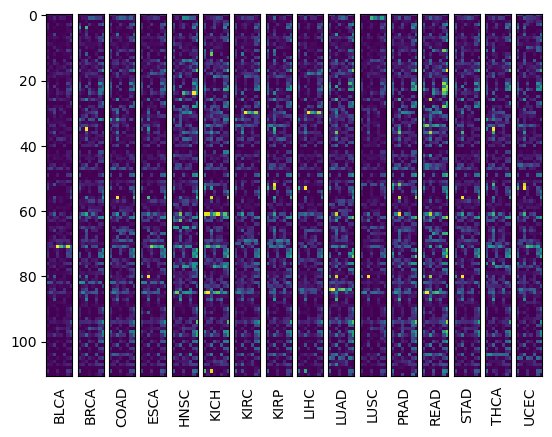

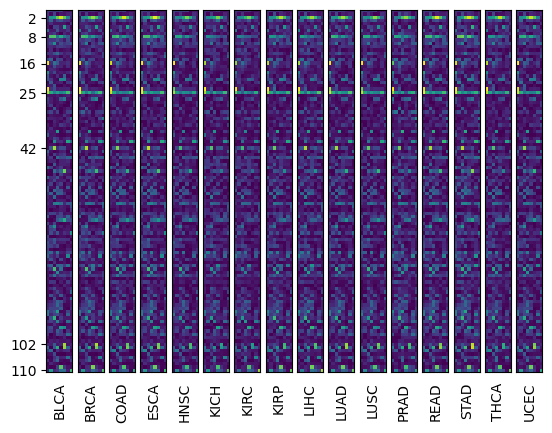

In [169]:
unique_cohorts = np.sort(np.unique(cohorts))
example_indices = [np.where((cohorts == element) & (types == 0.0))[0][0] for element in unique_cohorts]

lvl = 6

H = Hs[lvl]
H_grad = Hs_grad[lvl]

print("Hs shape: ", H.shape)
print("Hs_grad shape: ", H_grad.shape)

n_cols = len(example_indices)
fig, ax = plt.subplots(1, n_cols, figsize=(6.4, 4.8))
for i, ex in enumerate(example_indices):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = H[ex]
    ax[i].imshow(im, cmap='viridis')
    ax[i].set_xlabel('{}'.format(cohort_map[cohorts[ex]].upper()), rotation=90)
    ax[i].set_xticks([])
    if i == 0:
        pass
    else:
        ax[i].set_yticks([])
fig.savefig(path_images / 'embedding_examples.pdf')

fig, ax = plt.subplots(1, n_cols, figsize=(6.4, 4.8))
for i, ex in enumerate(example_indices):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = np.abs(H_grad[ex])
    ax[i].imshow(im, cmap='viridis')
    ax[i].set_xlabel('{}'.format(cohort_map[cohorts[ex]].upper()), rotation=90)
    ax[i].set_xticks([])
    if i == 0:
        ax[i].set_yticks([25,  16, 8,  2,  42, 102, 110,])
        ax[i].tick_params(labelsize=10)
    else:
        ax[i].set_yticks([])
fig.savefig(path_images / 'embedding_gradient_examples.pdf')


Now we analyze which genes are present in each cluster marked by the saliencies.
We will consider first how to summarize these images

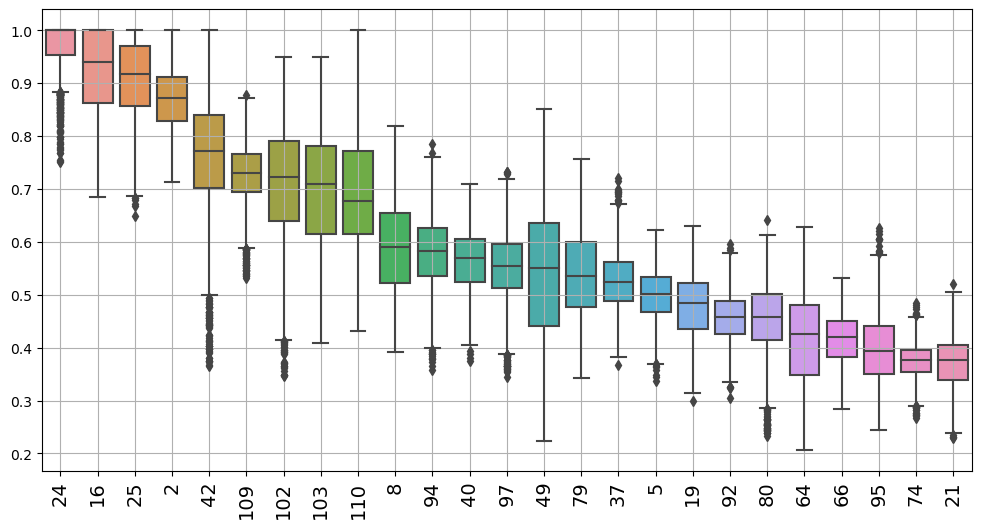

In [84]:
grad_max = np.max(np.abs(H_grad), axis=2)
grad_max = (grad_max - grad_max.min(axis=1, keepdims=True)) / (grad_max.max(axis=1, keepdims=True) - grad_max.min(axis=1, keepdims=True))
main_clusters = np.argsort(-np.median(grad_max, axis=0))

df_grad_max = pd.DataFrame(grad_max)
df_grad_max = df_grad_max.reindex(columns=main_clusters)

# fig, ax = plt.subplots(figsize=(12, 3))
# for k in range(5):
#     ax.plot(np.arange(0, 111), grad_max[k], label='Ex {}'.format(k))
# plt.show()
# print(main_clusters)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_grad_max.iloc[:, :25], ax=ax, whis=1.5)
ax.grid()
ax.xaxis.set_tick_params(rotation=90, labelsize=14)
fig.savefig(path_images / 'boxplot_cluster_importances.pdf')

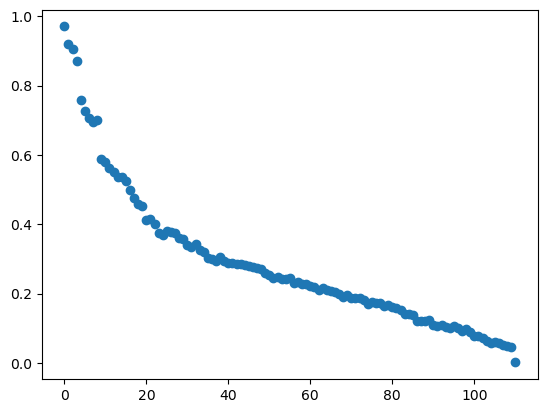

In [85]:
ranked_grads = grad_max.mean(axis=0)[main_clusters]
fig, ax = plt.subplots()
ax.scatter(np.arange(0, ranked_grads.shape[0]), ranked_grads)
plt.show()


Now let's get the parents from the graphs objects and use them to find the genes in the clusters

In [86]:
parents = []
for g in graphs:
    parents.append(g.cluster_indices.cpu().numpy())
parents.append(np.arange(0, 111))

from pooling_genomic.coarsening import get_nodes_in_cluster
nodes_in_clusters = get_nodes_in_cluster(parents, level=lvl+1)
print(len(nodes_in_clusters))


path_clusters = Path('/home/thomas/Documents/PoolingGenomicGNNs/outputs/tcga_cohort_and_tumor_rep0/clusters')
print(path_clusters)
genes = dataset.get_genes()
for c in main_clusters[:25]:
    nodes = nodes_in_clusters[c]
    df = pd.DataFrame(nodes, columns=['genes'])
    df['genes'] = df['genes'].apply(lambda x: genes[x].split('.')[1])

    path_out_csv = path_clusters / 'cluster_lvl{}_{}.csv'.format(lvl, c)
    df.to_csv(path_out_csv, index=False, header=False)


111
/home/thomas/Documents/PoolingGenomicGNNs/outputs/tcga_cohort_and_tumor_rep0/clusters


Now we will summarize the gradients for the whole data by showing the graph containing the supernodes colored by their importances

(2, 12321)
(2, 3600)


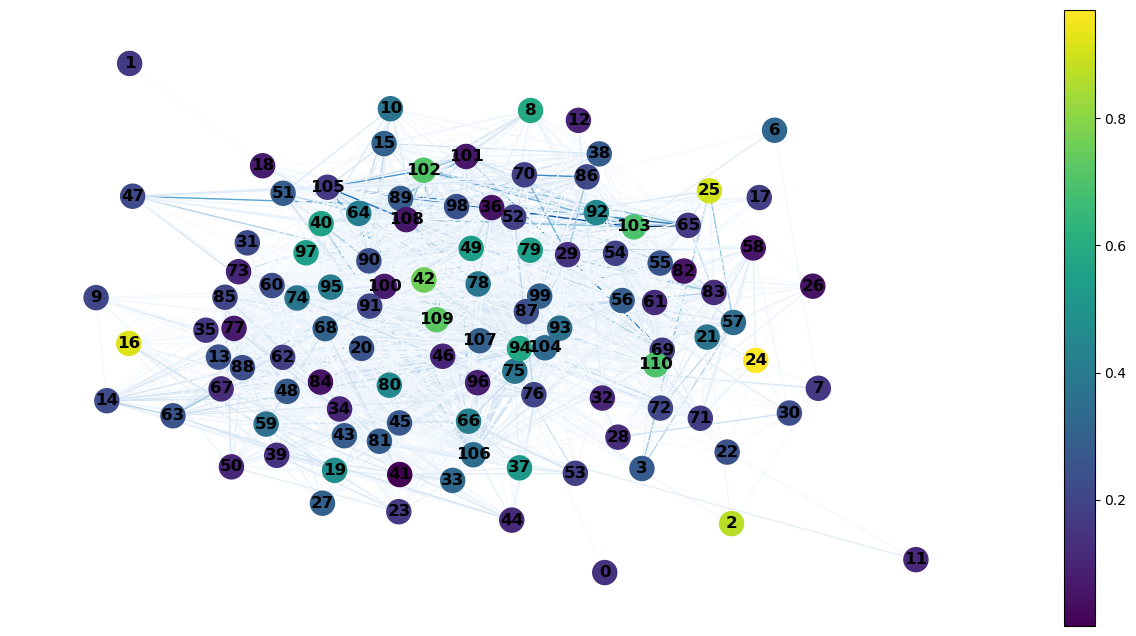

In [87]:
import networkx as nx


def draw_colored_graph(edges, weights, node_values):
    # Create an empty graph
    graph = nx.Graph()

    # Add edges to the graph with weights
    for (u, v), weight in zip(edges.transpose(), weights):
        graph.add_edge(u, v, weight=weight)

    # Create a list of color intensities based on node values
    node_colors = [node_values[node] for node in graph.nodes]

    edge_colors = [weight for _, _, weight in graph.edges.data("weight")]

    # Draw the graph with colored nodes
    pos = nx.kamada_kawai_layout(graph)  # Positions of the nodes
    fig, ax = plt.subplots(figsize=(16, 8))
    nx.draw(graph, pos, node_color=node_colors, cmap='viridis',
            with_labels=True, font_weight='bold', edge_color=edge_colors,
            width=1, edge_cmap=plt.cm.Blues, ax=ax)

    # Add a colorbar to show the color scale
    sm = plt.cm.ScalarMappable(cmap='viridis')
    sm.set_array(node_colors)
    fig.colorbar(sm,)

    # Display the graph
    plt.show()
    fig.savefig(path_images / 'graph.pdf')


grads_mean = grad_max.mean(axis=0)
graphs2 = load_graph_levels(
    path_levels=path_levels, n_levels=8, device=device
)
edges = graphs2[7].edge_index.numpy()
weights = graphs2[7].edge_weight.numpy()
th = 0.06
valid_edges = edges[:, weights > th]
valid_weights = weights[weights > th]
print(edges.shape)
print(valid_edges.shape)

draw_colored_graph(valid_edges, valid_weights, grads_mean)

0.05778246 0.063618526 0.12140098586678505


(array([5.437e+03, 3.754e+03, 1.408e+03, 6.700e+02, 3.840e+02, 2.200e+02,
        1.520e+02, 1.100e+02, 5.400e+01, 3.600e+01, 2.400e+01, 1.000e+01,
        1.200e+01, 1.400e+01, 8.000e+00, 1.000e+01, 0.000e+00, 2.000e+00,
        2.000e+00, 2.000e+00, 2.000e+00, 2.000e+00, 4.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00]),
 array([0.        , 0.03333334, 0.06666667, 0.1       , 0.13333334,
        0.16666667, 0.2       , 0.23333333, 0.26666668, 0.3       ,
        0.33333334, 0.36666667, 0.4       , 0.43333334, 0.46666667,
        0.5       , 0.53333336, 0.56666666, 0.6       , 0.6333333 ,
        0.6666667 , 0.7       , 0.73333335, 0.76666665, 0.8       ,
        0.8333333 , 0.8666667 , 0.9       , 0.93333334, 0.96666664,
        1.        ], dtype=float32),
 <BarContainer object of 30 artists>)

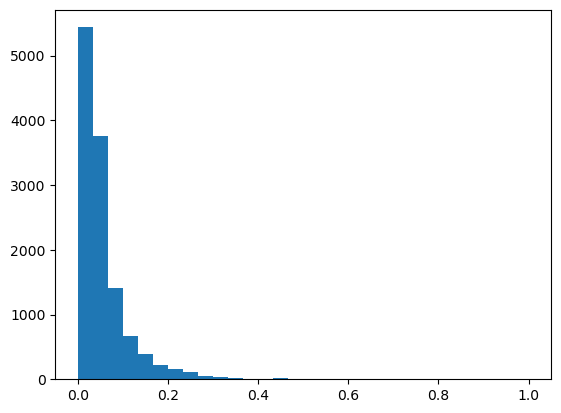

In [88]:
m = np.mean(weights)
st = np.std(weights)
print(m, st, m+1*st)
plt.hist(weights, bins=30)

#### Ancestor Analysis

Now let's try to analyze the parents of the main clusters to build a small tree of the importances

In [123]:
cluster_indices = [24, 16, 25, 2, 42, 109, 102, 103]
clusters = {}
for ci in cluster_indices:
    lv = 6
    desc = [ci]
    ancestors = []
    while lv > 0:
        # print(parents[lv])
        desc = np.flatnonzero(np.isin(parents[lv-1], desc))
        ancestors.append(desc)
        # print(desc)
        lv -= 1

    clusters[ci] = ancestors

for ci in cluster_indices:
    print(clusters[ci][0])


[ 33 172]
[ 14 145]
[ 13 128]
[3 6]
[75 80]
[150 236]
[167 228]
[210 330]


Let's compute importance values for lvl 5 (immediate ancestors of level 6). We want to see whether one of the ancestor is more important than other and perhaps make a pathway towards a set of genes.

/home/thomas/miniconda3/envs/pytorch112-cpu-env/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:996: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


Text(0.5, 1.0, 't-SNE of Embedding Gradients')

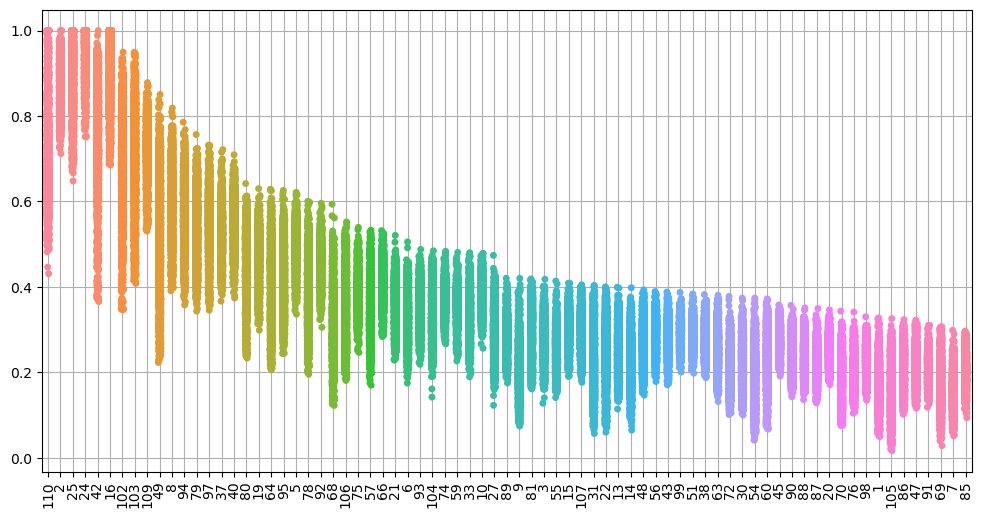

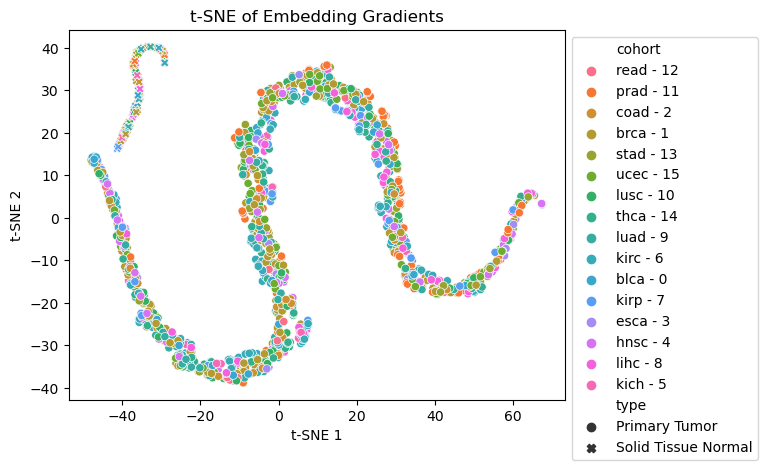

In [150]:
lvl = 6
H = Hs[lvl]
H_grad = Hs_grad[lvl]
grad_max = np.max(np.abs(H_grad), axis=2)
grad_max = (grad_max - grad_max.min(axis=1, keepdims=True)) / (grad_max.max(axis=1, keepdims=True) - grad_max.min(axis=1, keepdims=True))
main_clusters = np.argsort(-np.max(grad_max, axis=0))

df_grad_max = pd.DataFrame(grad_max)
df_grad_max = df_grad_max.reindex(columns=main_clusters)

fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(data=df_grad_max.iloc[:, :75], ax=ax)
ax.grid()
ax.xaxis.set_tick_params(rotation=90, labelsize=10)
# fig.savefig(path_images / 'boxplot_cluster_lvl{}_importances.pdf'.format(lvl))


# Make t-sne of the gradients at that level
n_ex, n_nodes, n_emb = Hs_grad[lvl].shape
# H_nodes = Hs_grad[lvl].reshape((n_ex, n_nodes*n_emb))
H_nodes = np.mean(Hs_grad[lvl], axis=2)
Xpc = H_nodes
# Xpc = PCA(n_components=2).fit_transform(Xpc)
Xpc = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=30, random_state=123, early_exaggeration=12, angle=0.5).fit_transform(Xpc)

cohort_map = dataset.cohorts_encoder.classes_
type_map = dataset.types_encoder.classes_
df_pc = pd.DataFrame(Xpc, columns=['t-SNE 1', 't-SNE 2'])
df_pc['cohort'] = cohorts
df_pc['cohort'] = df_pc['cohort'].apply(lambda x: f"{cohort_map[int(x)]} - {int(x)}").astype(str)
df_pc['type'] = types
df_pc['type'] = df_pc['type'].apply(lambda x: type_map[int(x)]).astype(str)

fig, ax = plt.subplots()
sns.scatterplot(data=df_pc, x='t-SNE 1', y='t-SNE 2', hue='cohort', style='type', ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('t-SNE of Embedding Gradients')

In [142]:
clusters[24]

[array([ 33, 172]),
 array([ 79, 179, 206, 355]),
 array([  17,  144,  198,  443,  689,  759, 1007, 1360]),
 array([  28,  248,  280,  375,  376,  649,  894,  935, 1181, 1186, 1229,
        1302, 1648, 1914, 2495, 3237]),
 array([ 161,  303,  464,  509,  572,  615,  674,  739,  746,  817, 1341,
        1422, 1553, 1661, 1713, 2126, 2192, 2494, 2496, 2580, 2611, 2724,
        2732, 2905, 3124, 3382, 3480, 4285, 4433, 4600, 5953, 6805]),
 array([  195,   678,  1174,  1252,  1528,  2602,  2608,  2756,  2847,
         3022,  3141,  3228,  3252,  3439,  3652,  3739,  3890,  4131,
         4186,  4246,  4622,  4686,  4996,  5151,  5223,  5227,  5299,
         5454,  5856,  6079,  6468,  6577,  6696,  6806,  6863,  6927,
         7177,  7201,  7563,  7871,  7983,  8095,  8096,  8269,  8330,
         8353,  8631,  8737,  9402,  9454,  9970, 10288, 10328, 10884,
        11069, 11388, 12534, 13294, 13339, 13924, 13999, 14008, 14042,
        14104])]

array([[<AxesSubplot:title={'center':'355'}>]], dtype=object)

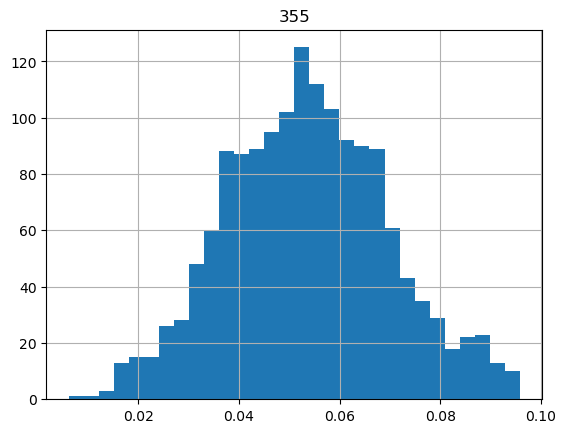

In [146]:
df_grad_max[[355]].hist(bins=30)

### Cohort Interpretation
Now we get will analyze the embeddings and gradients with respect to the classes.

In [4]:
import torch
import numpy as np
from torch.autograd import Variable


def measure_cohort_gradients(dataloader, max_batches=None):
    input_grads = []
    Hs = [[] for _ in range(len(model[0].Hs))]
    Hs_grad = [[] for _ in range(len(model[0].Hs_grad))]    
    cohorts = []
    types = []
    for i, batch in enumerate(dataloader, 0):
        if max_batches is not None:
            if i == max_batches:
                break
        
        x, t = batch
        x, t = x.to(device), [t[0].to(device), t[1].to(device)]

        X_var = Variable(x, requires_grad=True)
        y_var = Variable(t[0])
        scores = model(X_var)
        scores = torch.nn.functional.softmax(scores[0], dim=1)
        labels_scores = scores.gather(1, y_var.view(-1, 1)).squeeze()
        loss = -torch.sum(torch.log(labels_scores))

        loss.backward()
        with torch.no_grad():
            input_grads.append(X_var.grad.data.detach().cpu().numpy())
            cohorts.append(t[0].detach().cpu().numpy())
            types.append(t[1].detach().cpu().numpy())
            
            for i, (H, H_grad) in enumerate(zip(model[0].Hs, model[0].Hs_grad)):
                Hs[i].append(H.detach().cpu().numpy())
                Hs_grad[i].append(H_grad.detach().cpu().numpy())

    input_grads = np.concatenate(input_grads, axis=0)
    cohorts = np.concatenate(cohorts, axis=0)
    types = np.concatenate(types, axis=0)
    for lvl in range(len(Hs)):
        Hs[lvl] = np.concatenate(Hs[lvl], axis=0)
        Hs_grad[lvl] = np.concatenate(Hs_grad[lvl], axis=0)

    return input_grads, Hs, Hs_grad, cohorts, types

train_loader, test_loader = build_data_loaders(
    train_set, test_set, batch_size=batch_size, num_workers=num_workers, device=device, drop_last=True, shuffle=False
)
grads, Hs, Hs_grad, cohorts, types = measure_cohort_gradients(test_loader, None)
grads = np.abs(grads)

Hs shape:  (1536, 111, 8)
Hs_grad shape:  (1536, 111, 8)


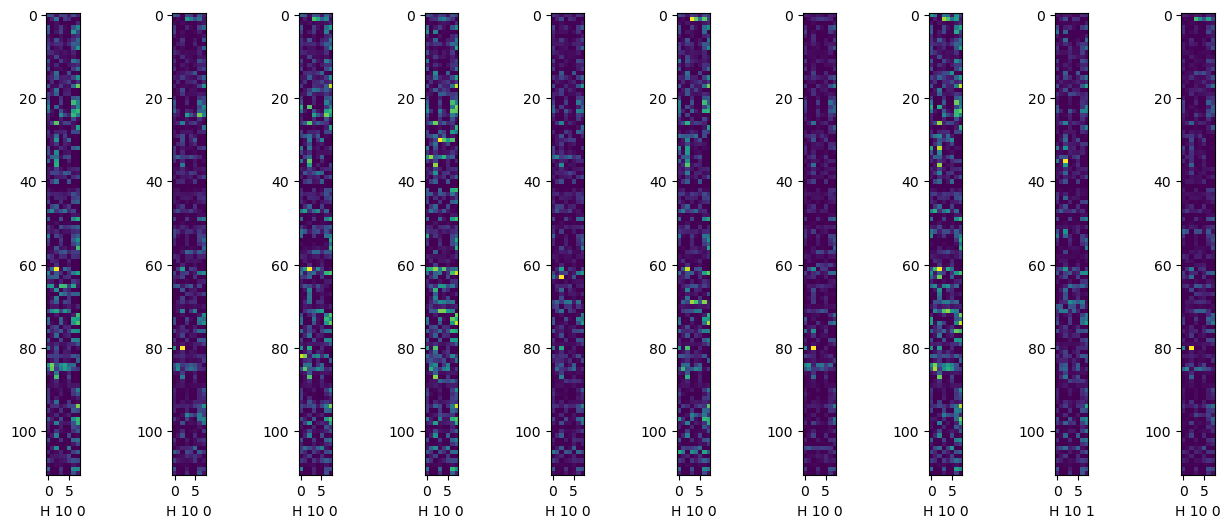

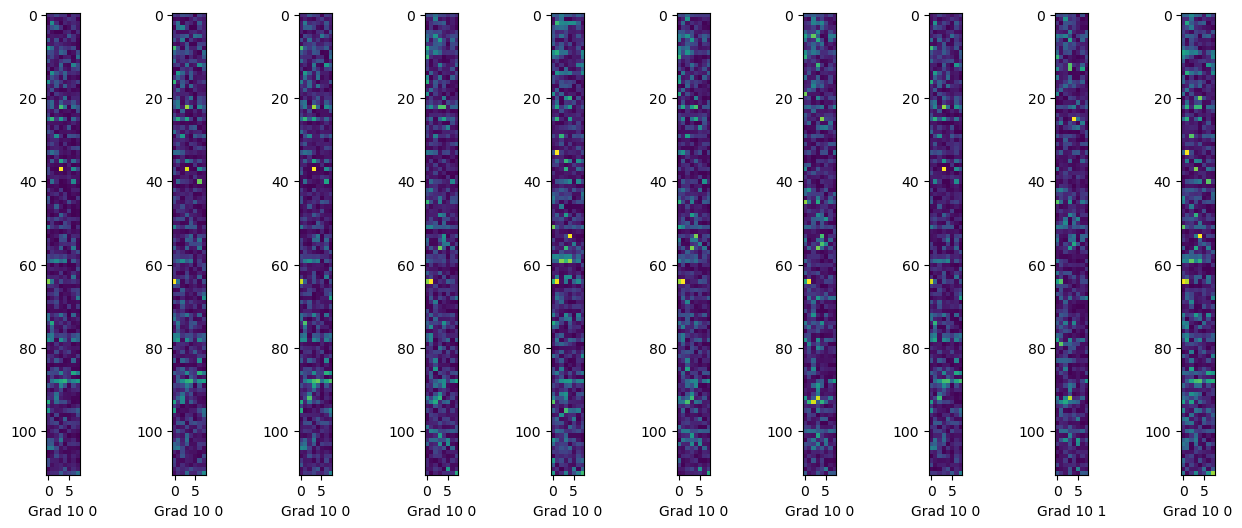

In [5]:
import matplotlib.pyplot as plt
unique_cohorts = np.sort(np.unique(cohorts))
example_indices = [np.where((cohorts == element) & (types == 0.0))[0][0] for element in unique_cohorts]

lvl = 6
H = Hs[lvl]
H_grad = Hs_grad[lvl]

print("Hs shape: ", H.shape)
print("Hs_grad shape: ", H_grad.shape)


sorted_idx = np.argsort(cohorts)
H_sorted = H[sorted_idx]
H_grad_sorted = H_grad[sorted_idx]
cohorts_sorted = cohorts[sorted_idx]
types_sorted = types[sorted_idx]

n_examples = 10
ex_0 = 1000
n_cols = len(example_indices)
fig, ax = plt.subplots(1, n_cols, figsize=(6.4, 4.8))
for i, ex in enumerate(example_indices):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = H_sorted[ex]
    ax[i].imshow(im)
    ax[i].set_xlabel('H {} {}'.format(cohorts_sorted[ex], int(types_sorted[ex])))

fig, ax = plt.subplots(1, n_examples, figsize=(16, 6))
for i, ex in enumerate(range(ex_0, ex_0+n_examples)):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = np.abs(H_grad_sorted[ex])
    ax[i].imshow(im)
    ax[i].set_xlabel('Grad {} {}'.format(cohorts_sorted[ex], int(types_sorted[ex])))

### Embeddings and Gradient of the Embeddings of the Cohort Outputs
We now plot the embeddings for each cohort, but the gradients are with respect to the inputs.

In [9]:
cohort_map = dataset.cohorts_encoder.classes_
type_map = dataset.types_encoder.classes_

Hs shape:  (1536, 111, 8)
Hs_grad shape:  (1536, 111, 8)


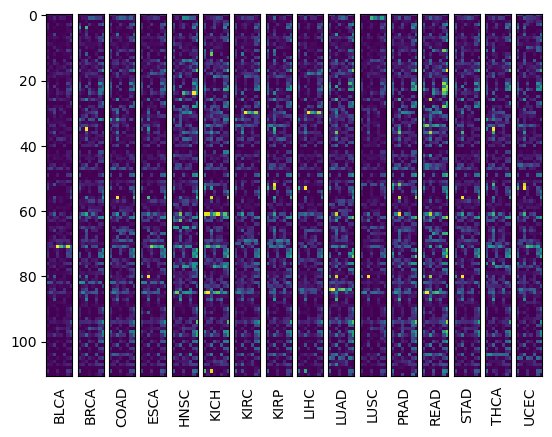

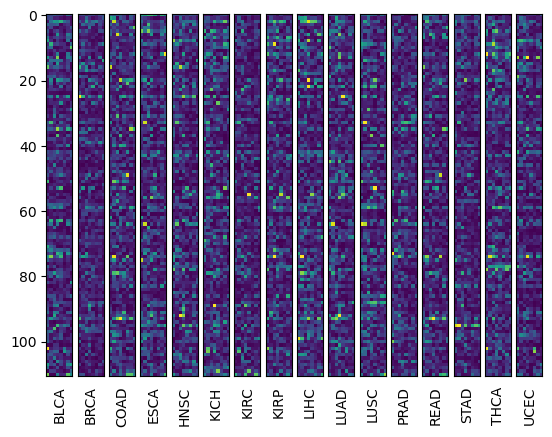

In [11]:
unique_cohorts = np.sort(np.unique(cohorts))
example_indices = [np.where((cohorts == element) & (types == 0.0))[0][0] for element in unique_cohorts]

lvl = 6

H = Hs[lvl]
H_grad = Hs_grad[lvl]

print("Hs shape: ", H.shape)
print("Hs_grad shape: ", H_grad.shape)

n_cols = len(example_indices)
fig, ax = plt.subplots(1, n_cols, figsize=(6.4, 4.8))
for i, ex in enumerate(example_indices):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = H[ex]
    ax[i].imshow(im, cmap='viridis')
    ax[i].set_xlabel('{}'.format(cohort_map[cohorts[ex]].upper()), rotation=90)
    ax[i].set_xticks([])
    if i == 0:
        pass
    else:
        ax[i].set_yticks([])
fig.savefig(path_images / 'embedding_examples_cohorts.pdf')

fig, ax = plt.subplots(1, n_cols, figsize=(6.4, 4.8))
for i, ex in enumerate(example_indices):
    # im = np.mean(Hs[i], axis=1).reshape(-1, 1)
    im = np.abs(H_grad[ex])
    ax[i].imshow(im, cmap='viridis')
    ax[i].set_xlabel('{}'.format(cohort_map[cohorts[ex]].upper()), rotation=90)
    ax[i].set_xticks([])
    if i == 0:
        # ax[i].set_yticks([25,  16, 8,  2,  42, 102, 110,])
        ax[i].tick_params(labelsize=10)
    else:
        ax[i].set_yticks([])
fig.savefig(path_images / 'embedding_gradient_examples_cohorts.pdf')

We have been using the max over the embeddings to determine the importance of each supernode.
So let's try to get the max and plot the cohorts using PCA

Let's make a list of examples that can pass the point I want to make: the saliencies look very similar independently of the cohort type

/home/thomas/miniconda3/envs/pytorch112-cpu-env/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:996: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


Text(0.5, 1.0, 't-SNE of Embeddings')

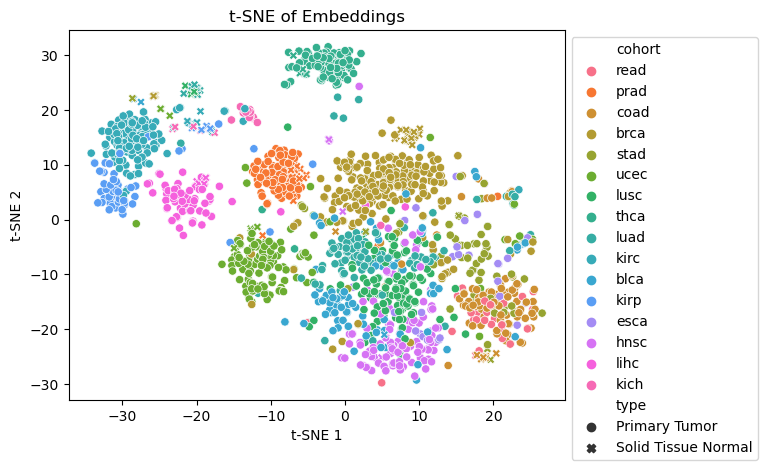

In [12]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# H_nodes = np.max(Hs[6], axis=2)
lvl = 6
n_ex, n_nodes, n_emb = Hs[lvl].shape
H_nodes = Hs[lvl].reshape((n_ex, n_nodes*n_emb))
# H_nodes = np.mean(Hs[lvl], axis=2)
Xpc = H_nodes
# Xpc = PCA(n_components=50).fit_transform(Xpc)
Xpc = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=50, random_state=123, early_exaggeration=12, angle=0.5).fit_transform(Xpc)

cohort_map = dataset.cohorts_encoder.classes_
type_map = dataset.types_encoder.classes_
df_pc = pd.DataFrame(Xpc, columns=['t-SNE 1', 't-SNE 2'])
df_pc['cohort'] = cohorts
df_pc['cohort'] = df_pc['cohort'].apply(lambda x: cohort_map[int(x)]).astype(str)
df_pc['type'] = types
df_pc['type'] = df_pc['type'].apply(lambda x: type_map[int(x)]).astype(str)

fig, ax = plt.subplots()
sns.scatterplot(data=df_pc, x='t-SNE 1', y='t-SNE 2', hue='cohort', style='type', ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('t-SNE of Embeddings')

/home/thomas/miniconda3/envs/pytorch112-cpu-env/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:996: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: '/home/thomas/Documents/PoolingGenomicGNNs/outputs/tcga_cohort_and_tumor_rep0/iamges/tsne_emb_saliencies_cohorts.pdf'

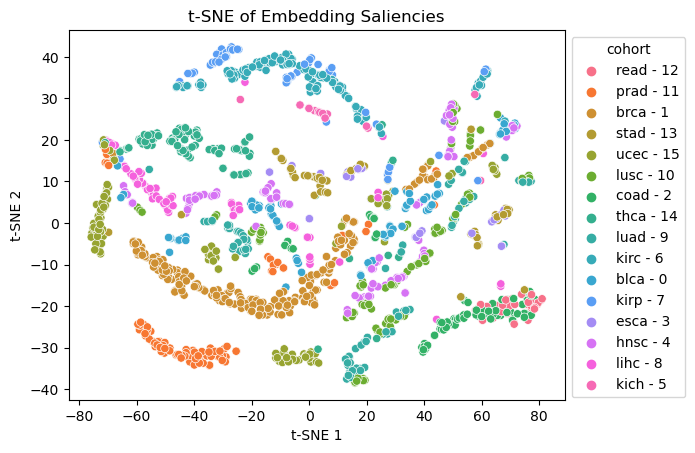

In [14]:
lvl = 6
n_ex, n_nodes, n_emb = Hs_grad[lvl].shape
H_nodes = np.abs(Hs_grad[lvl]).reshape((n_ex, n_nodes*n_emb))
# H_nodes = Hs_grad[lvl].reshape((n_ex, n_nodes*n_emb))
# H_nodes = np.max(Hs_grad[lvl], axis=2)
Xpc = H_nodes[types == 0.0]
# Xpc = PCA(n_components=2).fit_transform(Xpc)
Xpc = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=15, random_state=123, early_exaggeration=12, angle=0.5).fit_transform(Xpc)

cohort_map = dataset.cohorts_encoder.classes_
type_map = dataset.types_encoder.classes_
df_pc = pd.DataFrame(Xpc, columns=['t-SNE 1', 't-SNE 2'])
df_pc['cohort'] = cohorts[types == 0.0]
df_pc['cohort'] = df_pc['cohort'].apply(lambda x: f"{cohort_map[int(x)]} - {int(x)}").astype(str)
# df_pc['type'] = types
# df_pc['type'] = df_pc['type'].apply(lambda x: type_map[int(x)]).astype(str)

fig, ax = plt.subplots()
# sns.scatterplot(data=df_pc, x='t-SNE 1', y='t-SNE 2', hue='cohort', style='type', ax=ax)
sns.scatterplot(data=df_pc, x='t-SNE 1', y='t-SNE 2', hue='cohort', ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('t-SNE of Embedding Saliencies')
fig.savefig(path_images / 'images/tsne_emb_saliencies_cohorts.pdf')

Let's see which clusters are related to some specific cohorts using the saliencies.
Since they are so well distinguished in the t-SNE plot, they must be distinguished in the biological processes as well.

It seems, however, that using the multiple dimensions of the embeddings is important in this case.

Collect and save the clusters for some interesting examples

111
Cohort: blca
H grad shape: (86, 111, 8)
[ 53 110 102  33  16  63  79  74  25  51   2  92  96  20   8  64  73  35
 107  95  10   9  37  31  22  71  82  46  59  13  27  40  15  14  89  72
  91 109 108  68  42  44  29  49 105  93 103  97  86   1  19   7  78   3
  80   6  48  87  90  65  98  43  75   0  12  55 100 106  99  58  94  21
   5  45 104  17  54  56   4  77  83  88  50  85  23  57  28  81  26  67
  18  38  76  70  32  60  11  61  69  66  62  36  34  47  39  24  30  84
 101  52  41]
Cohort: brca
H grad shape: (220, 111, 8)
[ 25  93   2  22  49  74  79  21  53  95  20   5  39 110  27  13  17  16
  14 104  35  15  36  97  59  89  54  73  50   9  63 100   1  44  88  33
  56 107   3   4  90  19  80  68  55  64 109  71   8  67  38 102  83  96
  40  94  42  11  81  51  87  98  92 106  12  57  65  48  86  82  29  37
 103  99 101  78  60  76  70  61  77  10  72  52   0  69  66   6  43  58
  91  45  26  85  18  62  30  31   7 108  23  24  28  75  46  84  34  32
  47 105  41]
Cohort: coa

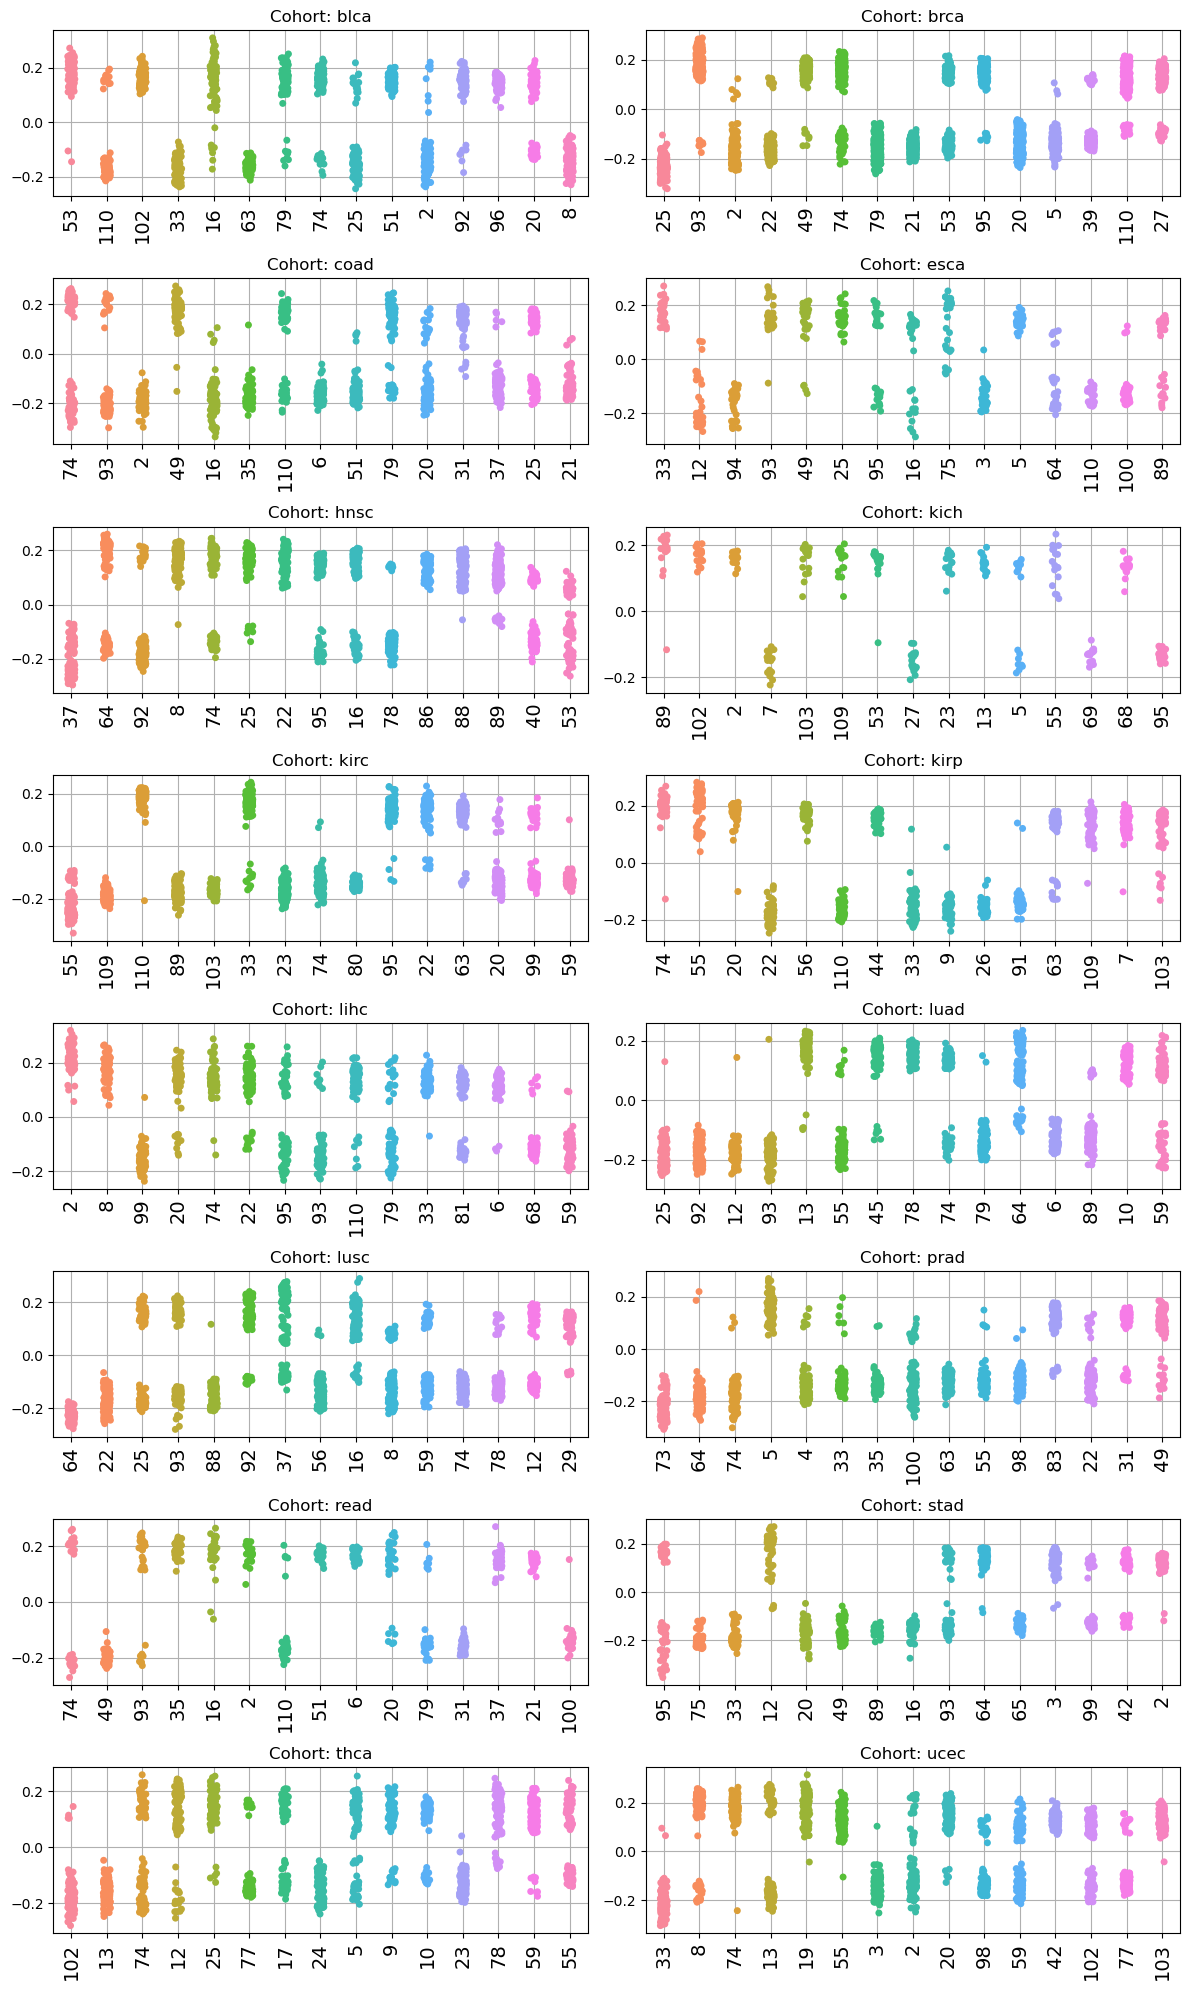

In [9]:
def plot_cluster_importances(Hs_grad, cohort_index, lvl, nodes_in_clusters, sample_type=0.0, use_abs=True, ax=None):
    c = cohort_map[cohort_index]
    print("Cohort: {}".format(c))
    H_grad = Hs_grad[lvl][types == sample_type]
    H_grad = H_grad[cohorts[types == sample_type] == cohort_index]
    print(f"H grad shape: {H_grad.shape}")

    if use_abs:
        H_grad = np.abs(H_grad)
    arg_grad_max = np.argmax(np.abs(H_grad), axis=2, keepdims=True)  # get highest index in absolute value from the node embeddings
    grad_max = np.take_along_axis(H_grad, indices=arg_grad_max, axis=2).squeeze(axis=2)

    # print(H_grad[:2, :5])
    # print(grad_max[:2, :5])
    # print(np.max(H_grad, axis=2)[:2, :5])
    # return

    # grad_max = (grad_max - grad_max.min(axis=1, keepdims=True)) / (grad_max.max(axis=1, keepdims=True) - grad_max.min(axis=1, keepdims=True))
    # grad_max = (grad_max - grad_max.mean(axis=1, keepdims=True))
    grad_max = grad_max / np.sqrt(np.sum(grad_max**2, axis=1, keepdims=True) )
    # main_clusters = np.argsort(-np.median(np.abs(grad_max), axis=0))
    # main_clusters = np.argsort(-np.mean(grad_max, axis=0))
    # main_clusters = np.argsort(-np.abs(np.mean(grad_max, axis=0)))
    main_clusters = np.argsort(-np.mean(np.abs(grad_max), axis=0))
    print(main_clusters)

    df_grad_max = pd.DataFrame(grad_max)
    df_grad_max = df_grad_max.reindex(columns=main_clusters)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    # sns.stripplot(data=df_grad_max.iloc[:, -25:], ax=ax)
    sns.stripplot(data=df_grad_max.iloc[:, :15], ax=ax)
    # sns.boxplot(data=df_grad_max.iloc[:, :50], ax=ax)
    ax.grid()
    ax.xaxis.set_tick_params(rotation=90, labelsize=14)
    ax.set_title("Cohort: {}".format(c))
    # fig.savefig(path_images / 'boxplot_cluster_importances.pdf')

    path_clusters = Path('/home/thomas/Documents/PoolingGenomicGNNs/outputs/tcga_cohort_and_tumor_rep0/clusters')
    genes = dataset.get_genes()
    for r, cl in enumerate(main_clusters[:5]):
        nodes = nodes_in_clusters[cl]
        df = pd.DataFrame(nodes, columns=['genes'])
        df['genes'] = df['genes'].apply(lambda x: genes[x].split('.')[1])

        path_out_csv = path_clusters / 'cluster_lvl{}_rank{}_cohort{}_type{}_abs{}_{}.csv'.format(
            lvl, r+1, c, int(sample_type), use_abs, cl)
        df.to_csv(path_out_csv, index=False, header=False)


parents = []
for g in graphs:
    parents.append(g.cluster_indices.cpu().numpy())
parents.append(np.arange(0, 111))

from pooling_genomic.coarsening import get_nodes_in_cluster
nodes_in_clusters = get_nodes_in_cluster(parents, level=lvl+1)
print(len(nodes_in_clusters))

fig, axs = plt.subplots(8, 2, figsize=(12, 20))
for i in range(8):
    for j in range(2):
        ax = axs[i][j]
        plot_cluster_importances(Hs_grad=Hs_grad, cohort_index=2*i + j, lvl=6, nodes_in_clusters=nodes_in_clusters, sample_type=0.0, use_abs=False, ax=ax)
fig.tight_layout()
fig.savefig('plot_gradient_cohorts.pdf')
fig.savefig('plot_gradient_cohorts.jpg')
